In [1]:
import sys
sys.path.append("../src")
from simulation_core.potential_force.norms import build_inv_norm_matrix
from simulation_core.potential_force.potentiel_force import build_potential_vector_force_torque_matrix
import numpy as np
from scipy.spatial.transform import Rotation

In [2]:
theta = 108 * 2*np.pi/360
r_oh = 0.5

In [3]:
n = 100
Lx, Ly, Lz = 20, 20, 20
R = Rotation.random(n)
quats = R.as_quat().reshape(4*n)
v = np.concatenate([
    -Lx/2 + Lx * np.random.rand(n),
    -Ly/2 + Ly * np.random.rand(n),
    -Lz/2 + Lz * np.random.rand(n),
    np.zeros(3 * n),
    quats
])
q_o = 1.0
q_h = 1.0
nbr_list = np.ones((n,n))- np.eye(n)

In [4]:
import quaternion as qtn

In [5]:
M_OO = np.zeros((n,n))
M_OH1 = np.zeros((n,n))
M_OH2 = np.zeros((n,n))
M_H1O = np.zeros((n,n))
M_H1H1 = np.zeros((n,n))
M_H1H2 = np.zeros((n,n))
M_H2O = np.zeros((n,n))
M_H2H1 = np.zeros((n,n))
M_H2H2 = np.zeros((n,n))

list_r = v[:3*n].reshape(n,3)
list_q = v[6*n:10*n].reshape(n,4)[:, [3,0,1,2]] 
L = np.array([Lx,Ly,Lz])

s = np.sin(theta/2)
c = np.cos(theta/2)

# Définition des positions des sites hydrogènes dans le repère de la molécule
r_h1 = r_oh * np.array([0,s,c])  
r_h2 = r_oh * np.array([0,-s,c])  

i_idx, j_idx = np.where(nbr_list)

# Définition de r et de q relatifs
ri = list_r[j_idx] - list_r[i_idx]             
rw = ri - L * np.round(ri / L)
q_i = qtn.from_float_array(list_q[i_idx])
q_j = qtn.from_float_array(list_q[j_idx])
q_i_rot = Rotation.from_quat(qtn.as_float_array(q_i)[:, [1,2,3,0]])
q = q_i.conjugate() * q_j

In [6]:
r = q_i_rot.apply(rw)
r

array([[  2.14226929,   3.86977242,  -2.32984322],
       [  1.07352784,  -4.92044446, -10.46417445],
       [  8.82663661,  -6.75521088,  -1.93133983],
       ...,
       [  0.23110641, -12.4942207 ,   0.19783662],
       [ -1.83636549,   6.90972525,   1.71818135],
       [ -8.80411987,   1.52932243,   5.94234633]], shape=(9900, 3))

In [7]:
u_h1 = qtn.rotate_vectors(q, r_h1) 
u_h2 = qtn.rotate_vectors(q, r_h2) 
u_h1

array([[ 0.17301304,  0.1571552 , -0.44200535],
       [-0.05800339, -0.49185256,  0.06867799],
       [ 0.12962477, -0.39718843,  0.27466119],
       ...,
       [ 0.18050098,  0.17160852, -0.43355497],
       [-0.31060889,  0.23212574, -0.31565766],
       [-0.35612339, -0.14103765,  0.32137908]], shape=(9900, 3))

In [8]:
M = build_inv_norm_matrix(n, v, Lx, Ly, Lz, nbr_list, theta, r_oh)

In [9]:
np.array(M[1])

array([[[[ 0.        ,  0.        ,  0.        ,  0.        ,
           0.        ,  0.        ],
         [ 0.42851706,  0.77406866, -0.46603738,  0.        ,
           0.        ,  0.        ],
         [ 0.09244176, -0.42370076, -0.9010728 ,  0.        ,
           0.        ,  0.        ],
         ...,
         [-0.63033615, -0.16294795, -0.75902852,  0.        ,
           0.        ,  0.        ],
         [ 0.54018263, -0.83621454,  0.09459372,  0.        ,
           0.        ,  0.        ],
         [ 0.55691437,  0.80157507, -0.21754033,  0.        ,
           0.        ,  0.        ]],

        [[-0.15304674,  0.42059094,  0.89424826,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        ,  0.        ,
           0.        ,  0.        ],
         [-0.00476754, -0.80513789, -0.59306851,  0.        ,
           0.        ,  0.        ],
         ...,
         [ 0.05185997,  0.95189863, -0.30199261,  0.        ,
           0.    

In [10]:
U, F = build_potential_vector_force_torque_matrix(n, v, Lx, Ly, Lz, nbr_list, theta, r_oh, q_o, q_h)

In [11]:
F

array([[ 3.87260112e+00,  2.30186995e+00,  2.82322064e+00,
        -1.92116900e+00,  3.16283000e+00,  5.37060555e-01],
       [ 3.12033362e-01, -1.13014503e+00,  1.74424592e+00,
        -4.53486037e+00, -2.01542866e+00, -8.41144425e-01],
       [ 4.95367504e-01,  4.72136423e-02,  1.30931175e+00,
        -1.68484833e-01, -6.87989933e-01,  8.66931635e-01],
       [-8.38200272e-01,  1.32129474e+00, -1.39911997e+00,
         3.44745763e-02,  2.04232210e-01, -1.85783051e-01],
       [-1.70853631e+00,  1.06816820e+00,  1.83798772e+00,
        -2.77976440e-03,  4.87590576e-01,  8.22533952e-01],
       [ 1.99726261e-01, -3.20511132e-01,  3.52089564e+00,
        -9.07479994e-01,  1.58378174e+00,  1.22891472e-01],
       [-1.82693704e+00, -4.76620614e-01, -5.33316317e-01,
        -1.14137816e-01, -6.48995353e-01, -1.21290273e+00],
       [-9.47726407e-01,  3.74457247e+00, -6.28107792e+00,
         1.40941533e+00, -6.54736517e+00, -5.60702359e+00],
       [ 2.60859143e+00,  2.88675202e-01,  1.417

In [28]:
import time
import matplotlib.pyplot as plt

In [ ]:
# list_n = np.array([50, 100, 250, 500, 750, 1000, 1500, 2000])
list_n = np.array(np.arange(200))
list_t = []

q_o = 1.0
q_h = 1.0
Lx, Ly, Lz = 20, 20, 20
theta = 108 * 2*np.pi/360
r_oh = 0.5

for n in list_n:
    R = Rotation.random(n)
    quats = R.as_quat().reshape(4*n)
    v = np.concatenate([
        -Lx/2 + Lx * np.random.rand(n),
        -Ly/2 + Ly * np.random.rand(n),
        -Lz/2 + Lz * np.random.rand(n),
        np.zeros(3 * n),
        quats
    ])
    nbr_list = np.ones((n,n))- np.eye(n)

    start = time.time()
    
    # U = build_potential_vector(n, v, Lx, Ly, Lz, nbr_list, theta, r_oh, q_o, q_h)

    t = time.time() - start
    list_t.append(t)

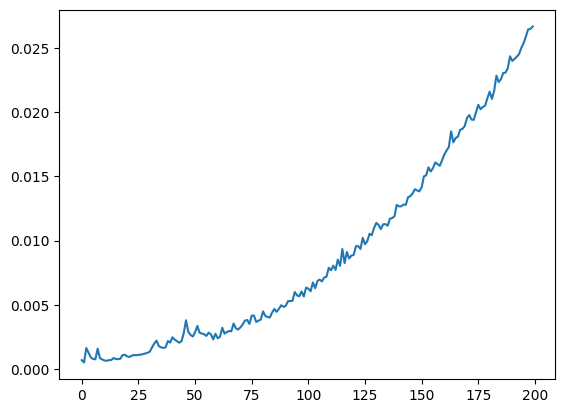

In [34]:
plt.plot(list_n, list_t)
plt.show()